# **Week 4 — Final Baseline RAG**
Embedding:
all-mpnet-base-v2

Chunk size:
400

Overlap:
100

Vector database:
FAISS

Retrieval:
Top-K

Baseline LLM:
Gemma 3 4B IT

In [1]:
from google.colab import files

uploaded = files.upload()

path = list(uploaded.keys())[0]

Saving cleaned_rag_document.txt to cleaned_rag_document.txt


# **Document Loader**

In [2]:
import re

def load_doc(path):
  with open(path, 'r', encoding = 'utf-8') as f:
    raw_text = f.read()

  return raw_text

# **Chunk Creation**

In [3]:
def create_chunks(text, chunk_size = 400, overlap = 100):
  start = 0
  chunks =[]

  while start < len(text):
    end = start + chunk_size
    chunks.append(text[start:end])

    start += chunk_size - overlap

  return chunks

# **Chunk Metadata**

In [4]:
sections = [
    "Retrieval-Augmented Generation",
    "Document Chunking",
    "Text Embeddings",
    "Vector Similarity",
    "Corrective RAG",
    "Self-RAG",
    "GraphRAG",
    "ReAct",
    "Hallucination",
    "Natural Language Inference",
    "Trust Score"
]

In [5]:
def create_chunk_metadata(chunks):

    metadata_chunks = []
    current_section = "Unknown"

    for i, chunk in enumerate(chunks):

        for section in sections:

            if section.lower() in chunk.lower():
                current_section = section
                break

        metadata_chunks.append({
            "chunk_id": i,
            "section": current_section,
            "source": path,
            "chunk_text": chunk
        })

    return metadata_chunks

## **MPNet Embeddings**

In [ ]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-mpnet-base-v2')

In [7]:
def generate_embeddings(chunks):
  embeddings = model.encode(chunks, convert_to_numpy = True)
  return embeddings

# **FAISS Index**

In [18]:
!pip install faiss-cpu

In [9]:
def create_faiss_index(embeddings, chunks):
  import faiss
  index = faiss.IndexFlatL2(embeddings.shape[1])
  index.add(embeddings)
  return index

# **Top K-Retrieval**

In [10]:
def retrieve(query, index, chunks_metadata, model, k=3):

    query_embedding = generate_embeddings([query])

    distances, indices = index.search(
        query_embedding,
        k
    )

    results = []

    for rank, (distance, index_id) in enumerate(
        zip(distances[0], indices[0]),
        start=1
    ):

        chunk = chunks_metadata[index_id]

        results.append({
            "rank": rank,
            "chunk_id": chunk["chunk_id"],
            "section": chunk["section"],
            "distance": float(distance),
            "text": chunk["chunk_text"]
        })

    return results

# **Context**

In [11]:
def build_context(results):
    context = "\n\n".join(
        result["text"] for result in results
    )

    return context

# **Create RAG prompt**

In [12]:
def RAG_prompt(context, query):

    prompt = f"""
You are a knowledge-based question answering assistant.

Answer the question using ONLY the information provided in the context.

If the context does not contain enough information to answer the question,
say that the information is not available in the provided context.

Do not use outside knowledge.
Do not invent facts.

Context:
{context}

Question:
{query}

Answer:
"""

    return prompt

# **Load Gemma 3**

In [13]:
!pip install -U llama-cpp-python \
--extra-index-url https://abetlen.github.io/llama-cpp-python/whl/cpu

Looking in indexes: https://pypi.org/simple, https://abetlen.github.io/llama-cpp-python/whl/cpu
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.9/23.9 MB 68.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 3.1 MB/s eta 0:00:00


In [14]:
from llama_cpp import Llama

print("llama-cpp-python imported successfully")

llama-cpp-python imported successfully


In [15]:
model_gemma = Llama.from_pretrained(
    repo_id="GijsW/gemma-3-4b-it-Q4_K_M-GGUF",
    filename="gemma-3-4b-it-q4_k_m.gguf",
    n_ctx=4096,
    n_gpu_layers=-1,
    verbose=False
)

print("Gemma 3 loaded successfully")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


./gemma-3-4b-it-q4_k_m.gguf: reconstructing file:   0%|          |  0.00B / 2.49GB            

./gemma-3-4b-it-q4_k_m.gguf: downloading bytes:           |  0.00B            

llama_kv_cache_iswa: using full-size SWA cache (ref: https://github.com/ggml-org/llama.cpp/pull/13194#issuecomment-2868343055)


Gemma 3 loaded successfully


# **Answer Generation Function**

In [16]:
def generate_answer(model, prompt):

    response = model.create_chat_completion(
        messages=[
            {
                "role": "user",
                "content": prompt
            }
        ],
        max_tokens=200,
        temperature=0.2
    )

    answer = response["choices"][0]["message"]["content"]

    return answer

In [19]:
query = "What is Retrieval-Augmented Generation?"

# Load the document
raw_text = load_doc(path)

# Create chunks
chunks = create_chunks(raw_text)

# Create chunk metadata
chunks_metadata = create_chunk_metadata(chunks)

# Generate embeddings for the chunks
embeddings = generate_embeddings([chunk['chunk_text'] for chunk in chunks_metadata])

# Create FAISS index
index = create_faiss_index(embeddings, chunks)

results = retrieve(
    query,
    index,
    chunks_metadata,
    model,
    k=3
)

context = build_context(results)

prompt = RAG_prompt(
    context,
    query
)

answer = generate_answer(
    model_gemma,
    prompt
)

print("========== QUESTION ==========")
print(query)

print("\n========== CONTEXT ==========")
print(context)

print("\n========== ANSWER ==========")
print(answer)

========== QUESTION ==========
What is Retrieval-Augmented Generation?

========== CONTEXT ==========
rective Retrieval-Augmented Generation, commonly called CRAG, extends traditional RAG by evaluating the quality of retrieved information before generating the final answer.

In a basic RAG system, retrieved documents are directly passed to the language model. In CRAG, the retrieved information is evaluated. If the retrieved information is considered insufficient or unreliable, the system can perfo

RAG Knowledge Base

1. Retrieval-Augmented Generation

Retrieval-Augmented Generation, commonly known as RAG, is a technique that combines information retrieval with large language model generation. Instead of relying only on information stored inside the parameters of a language model, a RAG system retrieves relevant information from an external knowledge base and provides that information as con

nformation is retrieved.

CRAG attempts to correct poor retrieval but primarily focuses on the

## **RAG function**

In [20]:
import time

def rag(query, k=3):

    start_time = time.perf_counter()

    results = retrieve(
        query,
        index,
        chunks_metadata,
        model,
        k=k
    )

    context = build_context(results)

    prompt = RAG_prompt(
        context,
        query
    )

    answer = generate_answer(
        model_gemma,
        prompt
    )

    end_time = time.perf_counter()

    return {
        "question": query,
        "retrieved_results": results,
        "context": context,
        "answer": answer,
        "total_time": end_time - start_time
    }

In [21]:
result = rag(
    "What is Retrieval-Augmented Generation?"
)

print(result["answer"])
print("Total time:", result["total_time"])

Retrieval-Augmented Generation, commonly known as RAG, is a technique that combines information retrieval with large language model generation. Instead of relying only on information stored inside the parameters of a language model, a RAG system retrieves relevant information from an external knowledge base and provides that information as context.
Total time: 47.34326163599985


# **Upload your 30-question document**

In [22]:
from google.colab import files

uploaded = files.upload()

question_path = list(uploaded.keys())[0]

Saving phase 1 questions.docx to phase 1 questions.docx


In [24]:
!pip install python-docx
from docx import Document

doc = Document(question_path)

questions = []

for table in doc.tables:

    for row in table.rows:

        cells = [
            cell.text.strip()
            for cell in row.cells
        ]

        if len(cells) >= 3:

            qid = cells[0]
            question = cells[1].replace("\n", " ").strip()
            expected_section = cells[2].replace("\n", " ").strip()

            if qid in [f"Q{i:02d}" for i in range(1, 31)]:

                questions.append({
                    "id": qid,
                    "question": question,
                    "expected_section": expected_section
                })

print("Questions:", len(questions))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 4.7 MB/s eta 0:00:00
Questions: 30


# **Run the baseline on all 30 questions**

In [25]:
import pandas as pd
import time

baseline_results = []

for count, q in enumerate(questions, start=1):

    print(f"Processing {count}/30: {q['id']}")

    start_time = time.perf_counter()

    results = retrieve(
        q["question"],
        index,
        chunks_metadata,
        model,
        k=3
    )

    context = build_context(results)

    prompt = RAG_prompt(
        context,
        q["question"]
    )

    answer = generate_answer(
        model_gemma,
        prompt
    )

    total_time = time.perf_counter() - start_time

    baseline_results.append({

        "question_id": q["id"],

        "question": q["question"],

        "expected_section":
            q["expected_section"],

        "retrieved_chunk_ids":
            [r["chunk_id"] for r in results],

        "retrieved_sections":
            [r["section"] for r in results],

        "distances":
            [r["distance"] for r in results],

        "context":
            context,

        "answer":
            answer,

        "total_time_seconds":
            total_time,

        "correct": "",
        "partially_correct": "",
        "incorrect": "",
        "unsupported": "",
        "hallucinated": ""
    })

Processing 1/30: Q01
Processing 2/30: Q02
Processing 3/30: Q03
Processing 4/30: Q04
Processing 5/30: Q05
Processing 6/30: Q06
Processing 7/30: Q07
Processing 8/30: Q08
Processing 9/30: Q09
Processing 10/30: Q10
Processing 11/30: Q11
Processing 12/30: Q12
Processing 13/30: Q13
Processing 14/30: Q14
Processing 15/30: Q15
Processing 16/30: Q16
Processing 17/30: Q17
Processing 18/30: Q18
Processing 19/30: Q19
Processing 20/30: Q20
Processing 21/30: Q21
Processing 22/30: Q22
Processing 23/30: Q23
Processing 24/30: Q24
Processing 25/30: Q25
Processing 26/30: Q26
Processing 27/30: Q27
Processing 28/30: Q28
Processing 29/30: Q29
Processing 30/30: Q30


# **Convert to DataFrame**

In [26]:
baseline_df = pd.DataFrame(
    baseline_results
)

baseline_df.head()

,question_id,question,expected_section,retrieved_chunk_ids,retrieved_sections,distances,context,answer,total_time_seconds,correct,partially_correct,incorrect,unsupported,hallucinated
0,Q01,What is Retrieval-Augmented Generation?,RAG,"[13, 0, 35]","[Retrieval-Augmented Generation, Retrieval-Aug...","[0.7036888599395752, 0.8700267672538757, 0.929...","rective Retrieval-Augmented Generation, common...","Retrieval-Augmented Generation, commonly known...",65.339776,,,,,
1,Q02,How does RAG use an external knowledge base?,RAG,"[0, 1, 2]","[Retrieval-Augmented Generation, Retrieval-Aug...","[0.4667448103427887, 0.7292532920837402, 0.849...",RAG Knowledge Base\n\n1. Retrieval-Augmented G...,RAG retrieves relevant information from an ext...,53.657245,,,,,
2,Q03,What are the main stages of a typical RAG pipe...,RAG,"[1, 4, 16]","[Retrieval-Augmented Generation, Document Chun...","[0.9491517543792725, 1.1042375564575195, 1.220...",retrieves relevant information from an extern...,A typical RAG pipeline contains several stages...,63.616163,,,,,
3,Q04,Why can RAG reduce hallucinations?,RAG,"[3, 25, 2]","[Hallucination, Hallucination, Hallucination]","[0.6718479990959167, 1.0650123357772827, 1.067...","to a language model, which generates the fina...",RAG can reduce hallucinations because the lang...,47.301929,,,,,
4,Q05,Does RAG guarantee that generated answers are ...,RAG,"[3, 0, 34]","[Hallucination, Retrieval-Augmented Generation...","[0.7887418270111084, 0.8993026614189148, 0.915...","to a language model, which generates the fina...","No, RAG does not guarantee that the generated ...",58.674532,,,,,


In [27]:
print("Total answers:", len(baseline_df))

Total answers: 30


# **Save the Week 4 baseline**

In [28]:
baseline_df.to_csv(
    "week4_baseline_results.csv",
    index=False
)

print("Baseline results saved.")

Baseline results saved.


In [29]:
files.download(
    "week4_baseline_results.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Answer Evaluation**

In [30]:
import pandas as pd

df = pd.read_csv("week4_baseline_results.csv")

print("Total questions:", len(df))

Total questions: 30


# **RESULT**
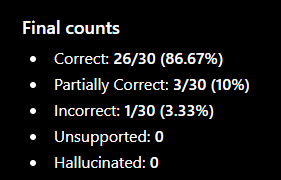